<h1 align="center"> Initial Plots </h1>

<br>
<i> Import necessary libraries: <i>

In [1]:
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis 
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import math
from matplotlib.patches import Ellipse
import time
import random
from sklearn.preprocessing import StandardScaler
np.random.seed(2)

import os
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr

### Matching Samples for Analysis

In [2]:
# Step 1: Load RNA-Seq data
df_rna = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/rna_counts/RNA_counts_141024.csv", header=None, low_memory=False)
df_rna_transposed = df_rna.transpose()
new_header = df_rna_transposed.iloc[1]
df_rna_transposed = df_rna_transposed[2:]
df_rna_transposed.columns = new_header
df_rna_transposed.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces

# Step 3: Filter RNA data for 'ENSG' columns
rna_cols = df_rna_transposed.filter(like='ENSG')

# Step 4: Load and merge image data
df_images = pd.read_excel("/home/kryan24/MRes_Ultrasound/data/metadata/RNA_Sample_Linking2.xlsx")
df_images.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces
df_images['Sample ID'] = df_images['Sample ID'].str.replace(' ', '_')
df_images["SURGICAL"] = df_images["SURGICAL"].str.strip() # Remove whitespaces from SURGICAL

df_merged = pd.merge(df_images, df_rna_transposed, left_on="Sample ID", right_on="Geneid")

# Step 5: Correct data quality issues
df_merged["Extraction site"] = df_merged["Extraction site"].str.strip()
df_merged["Extraction site"] = df_merged["Extraction site"].str.lower()

In [3]:
# Step 6: Read the CSV file into a DataFrame 
df_radiomics = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/metadata/radiomics_clinical_Barcroft_12_01_23.csv", low_memory=False)
# Remove first 2 columns
df_radiomics.drop(df_radiomics.columns[[0, 1]], axis=1, inplace=True)

# Filter columns
df_radiomics = df_radiomics.drop(df_radiomics.iloc[:, 3907:3950], axis=1)
df_radiomics["MAHCINE_CORECCTED"] = df_radiomics["MAHCINE_CORECCTED"].str.strip() # Remove whitespaces from MAHCINE_CORECCTED

# Step 7: Match radiomics data to metadata and filter DataFrame
df_radiomics_meta = df_merged[["Extraction site", "SURGICAL", "CASE ID", "CASE ID2"]]

# Step 8: Merge DataFrames
df_merged2 = pd.merge(df_radiomics_meta, df_radiomics, left_on="CASE ID", right_on="ID")

In [4]:
# Step 9: Correct data quality issues
df_merged2 = df_merged2.drop(["ID"], axis=1)

# Step 10: Keep the same samples for RNA as radiomics data
case_id_list = df_merged2["CASE ID"].tolist()
mask = df_merged["CASE ID"].isin(case_id_list)
df_merged = df_merged[mask]

In [5]:
# Check length of both sample dataframes
print("Number of rows in RNA samples:", df_merged.shape[0])
print("Number of rows in radiomics samples:", df_merged2.shape[0])

Number of rows in RNA samples: 36
Number of rows in radiomics samples: 36


### Filter Images and RNA Data

In [6]:
# Filter radiomics data 
rad_cols = df_merged2.drop(["Extraction site", "SURGICAL", "CASE ID", "CASE ID2", "MAHCINE_CORECCTED"], axis=1)

In [7]:
# Step 1: Prepare image filenames and filter data
image_directory = "/home/kryan24/MRes_Ultrasound/CLIPRNA/images_matched"
image_filenames_rna = []
image_filenames_rad = []
rna_data_filtered = []
rad_data_filtered = []
surgical_rna = []
surgical_rad = []
sample_count_rna = 0 
sample_count_rad = 0 

In [8]:
for index, row in df_merged.iterrows():

    case_id = str(row['CASE ID']).strip() if pd.notna(row['CASE ID']) else ''
    case_id2 = str(row['CASE ID2']).strip() if pd.notna(row['CASE ID2']) else ''

    for file_name in os.listdir(image_directory):
        if file_name.endswith('.nii.gz') and 'seg' not in file_name:
            if case_id in file_name or case_id2 in file_name:
                image_filenames_rna.append(file_name)
                rna_data_filtered.append(row[rna_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0))
                surgical_rna.append(row["SURGICAL"])
                sample_count_rna += 1
                break

print(f"Number of Samples: ", sample_count_rna)

Number of Samples:  31


In [9]:
for index, row in df_merged2.iterrows():

    case_id = str(row['CASE ID']).strip() if pd.notna(row['CASE ID']) else ''
    case_id2 = str(row['CASE ID2']).strip() if pd.notna(row['CASE ID2']) else ''

    for file_name in os.listdir(image_directory):
        if file_name.endswith('.nii.gz') and 'seg' not in file_name:
            if case_id in file_name or case_id2 in file_name:
                image_filenames_rad.append(file_name)
                rad_data_filtered.append(row[rad_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0))
                surgical_rad.append(row["SURGICAL"])
                sample_count_rad += 1
                break

print(f"Number of Samples: ", sample_count_rad)

Number of Samples:  31


In [10]:
flag = (surgical_rna == surgical_rad)
print(f"Matching Diagnoses: ", flag)

flag2 = (image_filenames_rna == image_filenames_rna)
print(f"Matching Images: ", flag2)

Matching Diagnoses:  True
Matching Images:  True


## Train Data

### Train-test Split

In [11]:
# Convert to DataFrame
rad_data_filtered = pd.DataFrame(rad_data_filtered)
# Convert to DataFrame
rna_data_filtered = pd.DataFrame(rna_data_filtered)

In [12]:
# Step 1: Split into train and test sets
rad_train, rad_test, rna_train, rna_test, surg_train, surg_test, img_train, img_test = train_test_split(rad_data_filtered, rna_data_filtered, surgical_rad, image_filenames_rad, test_size=0.2, random_state=4)

In [13]:
# Convert back to DataFrame
rad_train = pd.DataFrame(rad_train, columns=rad_data_filtered.columns)
rad_test = pd.DataFrame(rad_test, columns=rad_data_filtered.columns)
# Convert back to DataFrame
rna_train = pd.DataFrame(rna_train, columns=rna_data_filtered.columns)
rna_test = pd.DataFrame(rna_test, columns=rna_data_filtered.columns)

In [14]:
print(f"Number of RNA samples: ", rna_train.shape[0])
print(f"Number of radiomics samples: ", rad_train.shape[0])
print(f"Number of image filenames: ", len(img_train))
print(f"Number of diagnoses: ", len(surg_train))
print(f"Image filenames: ", img_train)
print(f"Diagnoses: ", surg_train)

Number of RNA samples:  24
Number of radiomics samples:  24
Number of image filenames:  24
Number of diagnoses:  24
Image filenames:  ['25961_2.nii.gz', '26425_-3.nii.gz', '25827_0006.nii.gz', 'j681_1.nii.gz', 'j681_1.nii.gz', '24354_0019.nii.gz', 'j681_1.nii.gz', '26604_0007.nii.gz', 'j681_1.nii.gz', 'j681_1.nii.gz', 'j681_1.nii.gz', 'J630_0008.nii.gz', 'j681_1.nii.gz', 'j681_1.nii.gz', 'j681_1.nii.gz', '24903_0011.nii.gz', '26417_1.nii.gz', '26428_0020.nii.gz', 'j681_1.nii.gz', 'j681_1.nii.gz', 'j681_1.nii.gz', '25970_2.nii.gz', 'j681_1.nii.gz', '26424_0007.nii.gz']
Diagnoses:  ['M-S', 'B-S', 'M-S', 'B-S', 'M-S', 'M-S', 'B-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'B-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S']


### Radiomics Tabular Data

In [15]:
# Scale radiomics sample counts
scaler = StandardScaler()
rad_df = pd.DataFrame(scaler.fit_transform(rad_train), columns=rad_data_filtered.columns)
rad_df.insert(0, "SURGICAL", surg_train)

In [16]:
rad_df

,SURGICAL,N.voxels,SNS_vol,SNS_area,SNS_s2v,SNS_sph,SNS_sph_dis,SNS_com_1,SNS_com_2,SNS_max3d,...,GLCM_sumVar_HHH_256gl,GLCM_sumEnt_HHH_256gl,GLCM_difVar_HHH_256gl,GLCM_difEnt_HHH_256gl,GLCM_AutoCorrel_HHH_256gl,GLCM_ClTend_HHH_256gl,GLCM_Homoge1_HHH_256gl,GLCM_IDMN_HHH_256gl,GLCM_IDN_HHH_256gl,GLCM_invVar_HHH_256gl
0,M-S,0.612920,0.612920,0.622141,0.210961,-0.840029,0.768626,0.726595,-0.845510,1.583887,...,-0.344102,0.078686,-0.229631,0.037679,1.244281,-0.344102,-0.267440,0.349113,0.242097,0.096881
1,B-S,-1.185825,-1.185825,-1.165876,2.883504,1.229450,-1.222994,-1.361868,1.111624,-1.185564,...,1.175049,0.995966,0.446026,0.871283,0.355544,1.175049,-0.981289,-0.775395,-1.080540,-0.846637
2,M-S,0.264351,0.264351,0.251235,-1.128624,-0.454564,0.346968,0.413261,-0.531391,-0.062004,...,2.031942,1.151435,2.422067,1.328018,0.707192,2.031942,-0.968921,-2.362730,-1.841771,-0.745477
3,B-S,0.509752,0.509752,0.518747,0.235019,-0.761140,0.673388,0.632351,-0.787205,-0.168103,...,-0.634564,-0.117650,-0.475680,-0.161342,-1.080907,-0.634564,-0.137998,0.573963,0.477213,0.369353
4,M-S,-0.452963,-0.452963,-0.448696,0.331218,0.182444,-0.334807,-0.352750,0.004013,-1.125713,...,0.819867,0.959025,-0.099899,0.821719,-1.629464,0.819867,-1.040872,-0.485544,-1.052534,-0.917301
5,M-S,0.058991,0.058991,0.045870,-1.154598,-0.314165,0.167569,0.238625,-0.434457,-0.592498,...,2.185250,1.237190,2.132692,1.334684,0.612952,2.185250,-1.063984,-2.244446,-1.875349,-0.890199
6,B-S,-1.227081,-1.227081,-1.235887,-0.699314,1.468839,-1.408043,-1.334538,1.388145,-1.430407,...,1.301607,0.858582,1.082618,0.819321,-1.570566,1.301607,-0.779944,-1.062090,-0.973251,-0.533675
7,M-S,-0.968241,-0.968241,-0.975081,-0.537879,0.976078,-1.028251,-0.973116,0.816892,-1.152918,...,-0.853261,-2.686225,-0.437114,-2.497178,0.529805,-0.853261,3.217075,0.712447,1.259591,-0.785910
8,M-S,-0.497920,-0.497920,-0.497229,0.127194,0.302542,-0.423935,-0.424048,0.142469,-0.679554,...,0.217438,0.358682,0.484069,0.358408,-1.296463,0.217438,-0.404644,-0.290382,-0.244860,0.016547
9,M-S,-0.415923,-0.415923,-0.418934,-0.165021,0.213963,-0.341033,-0.322861,0.057073,-0.652349,...,0.772042,0.605012,0.336725,0.386252,-0.189691,0.772042,-0.410998,-0.263315,-0.293307,-0.198299


### RNA Tabular Data

In [17]:
# Scale RNA sample counts
scaler = StandardScaler()
rna_df = pd.DataFrame(scaler.fit_transform(rna_train), columns=rna_data_filtered.columns)
rna_df.insert(0, "SURGICAL", surg_train)

In [18]:
rna_df

1,SURGICAL,ENSG00000279928,ENSG00000228037,ENSG00000142611,ENSG00000284616,ENSG00000157911,ENSG00000260972,ENSG00000224340,ENSG00000226374,ENSG00000229280,...,ENSG00000198886,ENSG00000210176,ENSG00000210184,ENSG00000210191,ENSG00000198786,ENSG00000198695,ENSG00000210194,ENSG00000198727,ENSG00000210195,ENSG00000210196
0,M-S,-0.464238,-0.067399,-1.158983,0.0,-0.808695,-0.208514,0.0,-0.267261,0.0,...,2.146869,-0.377964,-0.208514,-0.447214,0.892891,1.187892,1.166880,0.702181,0.0,0.457400
1,B-S,-0.464238,-0.051383,1.139207,0.0,-0.755375,-0.208514,0.0,-0.267261,0.0,...,1.686431,-0.377964,-0.208514,-0.447214,1.028480,0.550212,0.110083,2.253935,0.0,0.311836
2,M-S,-0.464238,-0.467788,0.477228,0.0,-0.371467,-0.208514,0.0,-0.267261,0.0,...,-0.580815,-0.377964,-0.208514,-0.447214,-0.625762,-1.038266,-0.946714,-0.319552,0.0,-0.157357
3,B-S,-0.464238,-0.531850,0.189955,0.0,0.620296,-0.208514,0.0,-0.267261,0.0,...,-0.665591,-0.377964,-0.208514,-0.447214,-0.807233,-0.712330,-0.154116,-0.229074,0.0,-0.751802
4,M-S,-0.464238,-0.275601,-0.009888,0.0,-0.321701,-0.208514,0.0,-0.267261,0.0,...,-0.552640,-0.377964,-0.208514,2.236068,0.290072,0.351234,0.638482,-0.093672,0.0,-0.826277
5,M-S,-0.464238,-0.547866,-1.171474,0.0,0.282599,-0.208514,0.0,-0.267261,0.0,...,-0.672281,-0.377964,-0.208514,-0.447214,-1.148517,-1.327484,-1.475113,-1.002497,0.0,-0.290057
6,B-S,-0.464238,-0.371694,0.077543,0.0,-0.666507,-0.208514,0.0,-0.267261,0.0,...,-0.865351,-0.377964,-0.208514,-0.447214,0.755323,1.319384,0.902681,-0.703189,0.0,-0.829662
7,M-S,0.649934,-0.099430,3.025222,0.0,0.023106,-0.208514,0.0,1.336306,0.0,...,1.059180,-0.377964,-0.208514,-0.447214,-0.037632,0.577820,-0.154116,1.109756,0.0,0.223820
8,M-S,-0.464238,0.365021,0.339837,0.0,-1.629832,-0.208514,0.0,-0.267261,0.0,...,-0.535390,-0.377964,-0.208514,-0.447214,-0.584591,-0.153306,-0.418316,-0.513085,0.0,-0.944083
9,M-S,-0.464238,-0.579897,-1.096533,0.0,1.288581,-0.208514,0.0,-0.267261,0.0,...,-0.784670,-0.377964,-0.208514,-0.447214,-1.024971,-0.933283,0.110083,-0.903980,0.0,-0.802580


### Radiomics - Principal Component Analysis (2 Components) - Train

#### All features

In [19]:
# Seperating out the features
rad_all = rad_df.drop(["SURGICAL"], axis=1)
# Seperating out the target
rad_class = rad_df[["SURGICAL"]]

# Create PCA with 2 components
rad_pca = PCA(n_components=2)
rad_prinComps = rad_pca.fit_transform(rad_all)

# Print DataFrame
df_rad_princComps = pd.DataFrame(data=rad_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_rad_princComps

,Principal Component 1,Principal Component 2
0,0.077202,-25.784863
1,31.735651,20.119360
2,68.300868,14.255262
3,-9.997222,-19.460509
4,10.203470,0.651923
5,68.388612,30.548739
6,49.409792,14.216021
7,-88.941618,79.538615
8,34.224922,-0.508738
9,20.075951,12.137508


In [20]:
# Percentage explained by each component
print(rad_pca.explained_variance_ratio_)

[0.38682385 0.14623296]


In [21]:
# Final dataframe for plotting the data for class
df_rad_pca_class = pd.concat([df_rad_princComps, rad_class], axis=1)

In [22]:
# Function needed to create ellipses for PCA
def eigsorted(cov):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    return vals[order], vecs[:,order]

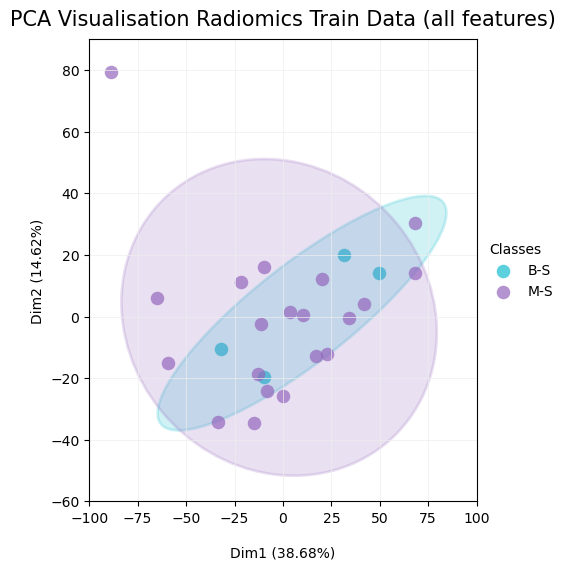

In [23]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")

for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_rad_pca_class["SURGICAL"] == target
    xdata = df_rad_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_rad_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("PCA Visualisation Radiomics Train Data (all features)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1 ({:.2f}%)'.format(rad_pca.explained_variance_ratio_[0]*100), fontsize=10, labelpad=15)
ax.set_xlim(-100,100)
ax.set_ylabel('Dim2 ({:.2f}%)'.format(rad_pca.explained_variance_ratio_[1]*100), fontsize=10)
ax.set_ylim(-60,90)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

#### Run LDA on the Original Dataset to Select Features

In [24]:
# Divide the dataset into features (X) and target variable (y)
X = rad_df.drop(["SURGICAL"], axis=1)
y = rad_df[["SURGICAL"]]

# Fit the LDA model
model = LinearDiscriminantAnalysis()
model.fit(X, y)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LinearDiscriminantAnalysis()

In [25]:
# Print coefficient table
coef_table = pd.DataFrame(list(X.columns)).copy()
coef_table.insert(len(coef_table.columns), "Coefficients", model.coef_.transpose())
coef_table

,0,Coefficients
0,N.voxels,0.004384
1,SNS_vol,0.004384
2,SNS_area,0.004060
3,SNS_s2v,-0.026068
4,SNS_sph,0.001309
...,...,...
3901,GLCM_ClTend_HHH_256gl,-0.002390
3902,GLCM_Homoge1_HHH_256gl,0.000651
3903,GLCM_IDMN_HHH_256gl,0.001976
3904,GLCM_IDN_HHH_256gl,0.002661


In [26]:
# Add absoloute coefficients column
coef_table["Absolute Coefficients"] = coef_table["Coefficients"].abs()
coef_table

,0,Coefficients,Absolute Coefficients
0,N.voxels,0.004384,0.004384
1,SNS_vol,0.004384,0.004384
2,SNS_area,0.004060,0.004060
3,SNS_s2v,-0.026068,0.026068
4,SNS_sph,0.001309,0.001309
...,...,...,...
3901,GLCM_ClTend_HHH_256gl,-0.002390,0.002390
3902,GLCM_Homoge1_HHH_256gl,0.000651,0.000651
3903,GLCM_IDMN_HHH_256gl,0.001976,0.001976
3904,GLCM_IDN_HHH_256gl,0.002661,0.002661


In [27]:
# Sort absolute coefficients 
coef_table = coef_table.sort_values(by="Absolute Coefficients", ascending=False)
coef_table

,0,Coefficients,Absolute Coefficients
3,SNS_s2v,-0.026068,0.026068
3761,FD_max_HHH_64gl,0.024132,0.024132
3328,FD_max_HHL_64gl,0.024132,0.024132
1970,FD_min_LHH_32gl,-0.023076,0.023076
1537,FD_min_LHL_32gl,-0.023076,0.023076
...,...,...,...
1789,FD_max_LHH_4gl,0.000000,0.000000
1790,FD_min_LHH_4gl,0.000000,0.000000
2223,FD_min_HLL_4gl,0.000000,0.000000
3089,FD_min_HHL_4gl,0.000000,0.000000


In [28]:
# Store top 1000 features
top_1000_rad = coef_table[0].head(1000).to_list()

In [29]:
# Seperating out the features
rad_1000 = rad_df.drop(["SURGICAL"], axis=1)
# Only keep the top 1000 features
rad_1000 = rad_1000.loc[:, rad_1000.columns.isin(top_1000_rad)]
# Seperating out the target
rad_class = rad_df[["SURGICAL"]]

# Create PCA with 2 components
rad_pca = PCA(n_components=2)
rad_prinComps = rad_pca.fit_transform(rad_1000)

# Print DataFrame
df_rad_princComps = pd.DataFrame(data=rad_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_rad_princComps

,Principal Component 1,Principal Component 2
0,-3.165292,19.063340
1,13.995165,-17.359916
2,23.820442,-4.338533
3,-7.371543,14.428988
4,6.304511,-2.512513
5,30.775742,-27.914394
6,16.318135,-0.293050
7,-29.190382,-22.698261
8,19.792167,10.847770
9,15.764544,5.628498


In [30]:
# Percentage explained by each component
print(rad_pca.explained_variance_ratio_)

[0.25018921 0.14230505]


In [31]:
# Final dataframe for plotting the data for class
df_rad_pca_class = pd.concat([df_rad_princComps, rad_class], axis=1)

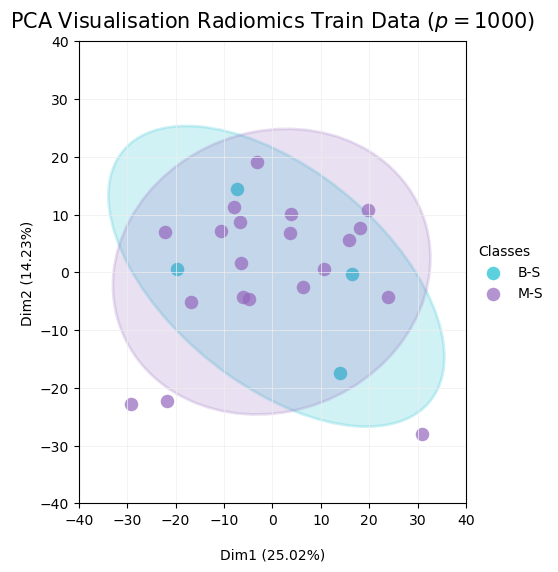

In [32]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")

for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_rad_pca_class["SURGICAL"] == target
    xdata = df_rad_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_rad_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("PCA Visualisation Radiomics Train Data ($p=1000$)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1 ({:.2f}%)'.format(rad_pca.explained_variance_ratio_[0]*100), fontsize=10, labelpad=15)
ax.set_xlim(-40,40)
ax.set_ylabel('Dim2 ({:.2f}%)'.format(rad_pca.explained_variance_ratio_[1]*100), fontsize=10)
ax.set_ylim(-40,40)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

#### Spearman Rho Correlation Coefficient

In [33]:
# Seperating out the features
rad_all = rad_df.drop(["SURGICAL"], axis=1)
# Seperating out the target
rad_class_cat = pd.Categorical(rad_df["SURGICAL"].astype("category")).codes

In [34]:
thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

def spearman_thresh_function(features, target, thresholds):
    threshold_list = []
    num_features = []

    column_names = features.columns.tolist()

    for threshold in thresholds:
        threshold_list.append(threshold)
        count = 0
        for column in column_names:
            corr, pval = spearmanr(features[column], target)
            if (corr != 0.9):
                if (corr >= threshold and corr <= threshold+1):
                    count += 1
            else:
                if (corr >= threshold):
                    count += 1
        num_features.append(count)

    return threshold_list, num_features

In [35]:
rad_thresholds, rad_threshold_counts = spearman_thresh_function(rad_all, rad_class_cat, thresholds)

/tmp/ipykernel_60409/673404981.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(features[column], target)


In [36]:
threshold_df = pd.DataFrame(
    {
        "Threshold": map(str, rad_thresholds),
        "Feature Count": rad_threshold_counts
    }
)

threshold_df

,Threshold,Feature Count
0,0,2054
1,0.1,1245
2,0.2,492
3,0.3,97
4,0.4,14
5,0.5,2
6,0.6,0
7,0.7,0
8,0.8,0
9,0.9,0


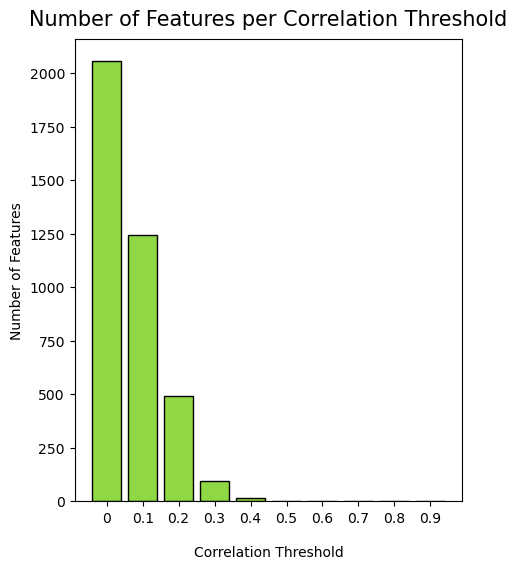

In [37]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.bar(threshold_df["Threshold"], threshold_df["Feature Count"], color="#8FD744FF", edgecolor="black")
ax.set_title("Number of Features per Correlation Threshold", fontsize = 15, pad=10)
ax.set_xlabel("Correlation Threshold", fontsize=10, labelpad=15)
ax.set_ylabel("Number of Features", fontsize=10)
plt.show()

In [38]:
def spearman_df_function(features, target, threshold):
    feature_names = []
    feature_correlations = []
    
    column_names = features.columns.tolist()

    for column in column_names:
        corr, pval = spearmanr(features[column], target)
        if (corr > threshold):
            feature_names.append(column)
            feature_correlations.append(corr)

    return feature_names, feature_correlations

In [39]:
rad_feature_names, rad_feature_correlations = spearman_df_function(rad_all, rad_class_cat, 0.3)

/tmp/ipykernel_60409/189007027.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(features[column], target)


In [40]:
spearman_df = pd.DataFrame(
    {
        "Features": rad_feature_names,
        "Correlations": rad_feature_correlations
    }
)

spearman_df

,Features,Correlations
0,SNS_max3d,0.395797
1,NGTDM_Busyne_8gl,0.306878
2,GLCM_Varian_8gl,0.323029
3,GLCM_ClProm_8gl,0.306878
4,GLCM_sumVar_8gl,0.306878
...,...,...
92,GLSZM_LzoneHiGl_HHH_32gl,0.339181
93,FD_lacunarity_HHH_128gl,0.306878
94,FD_sd_HHH_256gl,0.323029
95,FD_var_HHH_256gl,0.323029


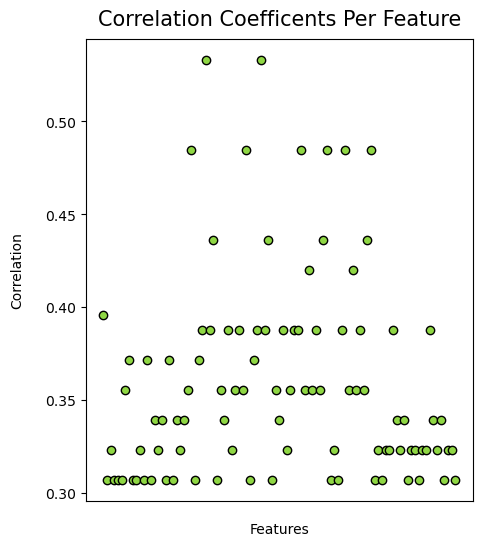

In [41]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.scatter(spearman_df["Features"], spearman_df["Correlations"], color="#8FD744FF", edgecolors="black")
ax.set_title("Correlation Coefficents Per Feature", fontsize = 15, pad=10)
ax.set_xlabel("Features", fontsize=10, labelpad=15)
ax.set_ylabel("Correlation", fontsize=10, labelpad=15)

plt.tick_params(bottom=False, labelbottom=False)
plt.show()

In [42]:
# Store spearman features
spearman_rad = spearman_df["Features"].to_list()

In [43]:
# Seperating out the features
rad_spear = rad_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
rad_spear = rad_spear.loc[:, rad_spear.columns.isin(spearman_rad)]
# Seperating out the target
rad_class = rad_df[["SURGICAL"]]

# Create PCA with 2 components
rad_pca = PCA(n_components=2)
rad_prinComps = rad_pca.fit_transform(rad_spear)

# Print DataFrame
df_rad_princComps = pd.DataFrame(data=rad_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_rad_princComps

,Principal Component 1,Principal Component 2
0,4.417699,-2.039711
1,-8.017992,-4.109957
2,6.389510,0.025911
3,-4.156837,-3.067603
4,-1.209996,-2.254431
5,6.164846,-0.551461
6,-5.718547,-3.549986
7,-3.137225,9.817663
8,-3.943533,-4.630268
9,-1.654833,-0.087200


In [44]:
# Percentage explained by each component
print(rad_pca.explained_variance_ratio_)

[0.31629071 0.19282688]


In [45]:
# Final dataframe for plotting the data for class
df_rad_pca_class = pd.concat([df_rad_princComps, rad_class], axis=1)

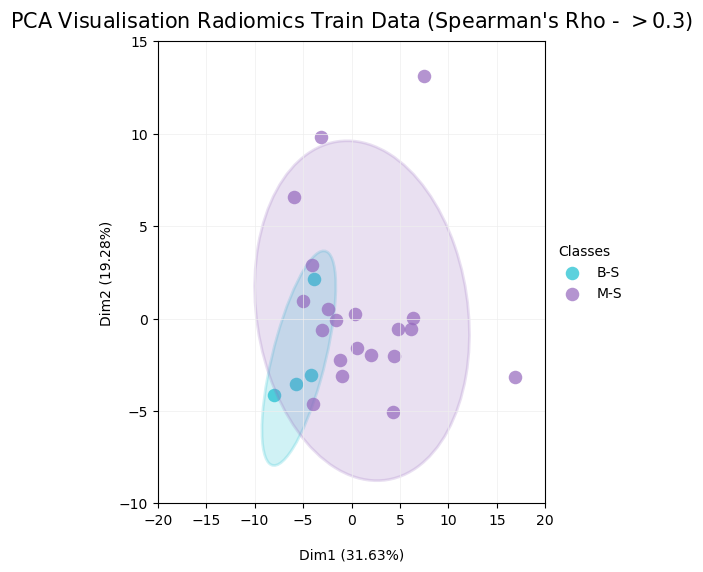

In [46]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")

for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_rad_pca_class["SURGICAL"] == target
    xdata = df_rad_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_rad_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("PCA Visualisation Radiomics Train Data (Spearman's Rho - $ > 0.3$)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1 ({:.2f}%)'.format(rad_pca.explained_variance_ratio_[0]*100), fontsize=10, labelpad=15)
ax.set_xlim(-20,20)
ax.set_ylabel('Dim2 ({:.2f}%)'.format(rad_pca.explained_variance_ratio_[1]*100), fontsize=10)
ax.set_ylim(-10,15)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

### RNA - Principal Component Analysis (2 Components) - Train

#### All features

In [47]:
# Seperating out the features
rna_all = rna_df.drop(["SURGICAL"], axis=1)
# Seperating out the target
rna_class = rna_df[["SURGICAL"]]

# Create PCA with 2 components
rna_pca = PCA(n_components=2)
rna_prinComps = rna_pca.fit_transform(rna_all)

# Create DataFrame
df_rna_princComps = pd.DataFrame(data=rna_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_rna_princComps

,Principal Component 1,Principal Component 2
0,-126.460139,-11.948193
1,54.101891,-20.327543
2,103.340818,22.720320
3,113.720740,33.552763
4,67.979185,-29.975991
5,-70.012358,-17.428381
6,92.842923,0.367302
7,34.953942,-17.944029
8,-14.958710,-112.988621
9,70.097905,31.278249


In [48]:
# Percentage explained by each component
print(rna_pca.explained_variance_ratio_)

[0.11292803 0.09416301]


In [49]:
# Final dataframe for plotting the data for class
df_rna_pca_class = pd.concat([df_rna_princComps, rna_class], axis=1)

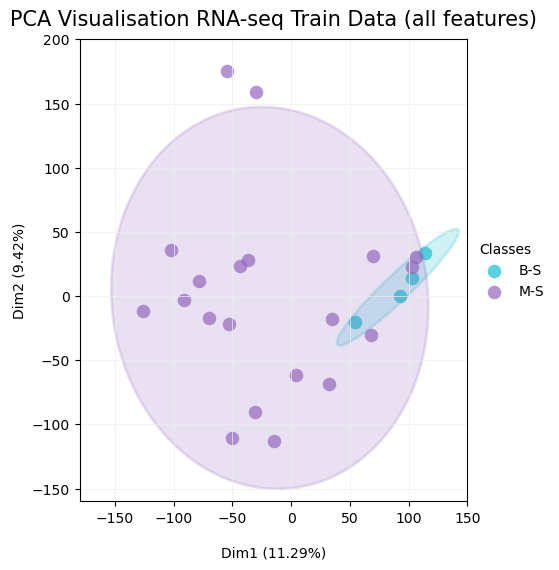

In [50]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")

for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_rna_pca_class["SURGICAL"] == target
    xdata = df_rna_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_rna_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("PCA Visualisation RNA-seq Train Data (all features)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1 ({:.2f}%)'.format(rna_pca.explained_variance_ratio_[0]*100), fontsize=10, labelpad=15)
ax.set_xlim(-180,150)
ax.set_ylabel('Dim2 ({:.2f}%)'.format(rna_pca.explained_variance_ratio_[1]*100), fontsize=10)
ax.set_ylim(-160,200)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

#### Run LDA on the Original Dataset to Select Features

In [51]:
# Divide the dataset into features (X) and target variable (y)
X = rna_df.drop(["SURGICAL"], axis=1)
y = rna_df[["SURGICAL"]]

# Fit the LDA model
model = LinearDiscriminantAnalysis()
model.fit(X, y)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LinearDiscriminantAnalysis()

In [52]:
# Print coefficient table
coef_table = pd.DataFrame(list(X.columns)).copy()
coef_table.insert(len(coef_table.columns), "Coefficients", model.coef_.transpose())
coef_table

,0,Coefficients
0,ENSG00000279928,-1.398763e-04
1,ENSG00000228037,5.427000e-05
2,ENSG00000142611,6.912960e-05
3,ENSG00000284616,-5.378145e-19
4,ENSG00000157911,8.994024e-05
...,...,...
63182,ENSG00000198695,9.741940e-05
63183,ENSG00000210194,4.902233e-05
63184,ENSG00000198727,3.272676e-06
63185,ENSG00000210195,0.000000e+00


In [53]:
# Add absoloute coefficients column
coef_table["Absolute Coefficients"] = coef_table["Coefficients"].abs()
coef_table

,0,Coefficients,Absolute Coefficients
0,ENSG00000279928,-1.398763e-04,1.398763e-04
1,ENSG00000228037,5.427000e-05,5.427000e-05
2,ENSG00000142611,6.912960e-05,6.912960e-05
3,ENSG00000284616,-5.378145e-19,5.378145e-19
4,ENSG00000157911,8.994024e-05,8.994024e-05
...,...,...,...
63182,ENSG00000198695,9.741940e-05,9.741940e-05
63183,ENSG00000210194,4.902233e-05,4.902233e-05
63184,ENSG00000198727,3.272676e-06,3.272676e-06
63185,ENSG00000210195,0.000000e+00,0.000000e+00


In [54]:
# Sort absolute coefficients 
coef_table = coef_table.sort_values(by="Absolute Coefficients", ascending=False)
coef_table

,0,Coefficients,Absolute Coefficients
13207,ENSG00000240135,-0.001196,0.001196
36010,ENSG00000204403,-0.001132,0.001132
10462,ENSG00000242880,-0.001072,0.001072
2932,ENSG00000201868,0.001027,0.001027
4200,ENSG00000162494,-0.001005,0.001005
...,...,...,...
44849,ENSG00000258402,0.000000,0.000000
7440,ENSG00000230327,0.000000,0.000000
7441,ENSG00000283058,0.000000,0.000000
44842,ENSG00000280494,0.000000,0.000000


In [55]:
# Store top 1000 features
top_1000_rna = coef_table[0].head(1000).to_list()

In [56]:
# Seperating out the features
rna_1000 = rna_df.drop(["SURGICAL"], axis=1)
# Only keep the top 1000 features
rna_1000 = rna_1000.loc[:, rna_1000.columns.isin(top_1000_rna)]
# Seperating out the target
rna_class = rna_df[["SURGICAL"]]

# Create PCA with 2 components
rna_pca = PCA(n_components=2)
rna_prinComps = rna_pca.fit_transform(rna_1000)

# Create DataFrame
df_rna_princComps = pd.DataFrame(data=rna_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_rna_princComps

,Principal Component 1,Principal Component 2
0,-19.805413,-2.535643
1,13.028668,-0.793716
2,30.371476,-4.468305
3,65.763992,-16.535931
4,13.572577,-3.726812
5,-17.625760,-2.771956
6,38.487985,-2.556413
7,-3.541041,0.549222
8,-11.985963,-0.706952
9,-3.967700,-1.585890


In [57]:
# Percentage explained by each component
print(rna_pca.explained_variance_ratio_)

[0.48589546 0.15425473]


In [58]:
# Final dataframe for plotting the data for class
df_rna_pca_class = pd.concat([df_rna_princComps, rna_class], axis=1)

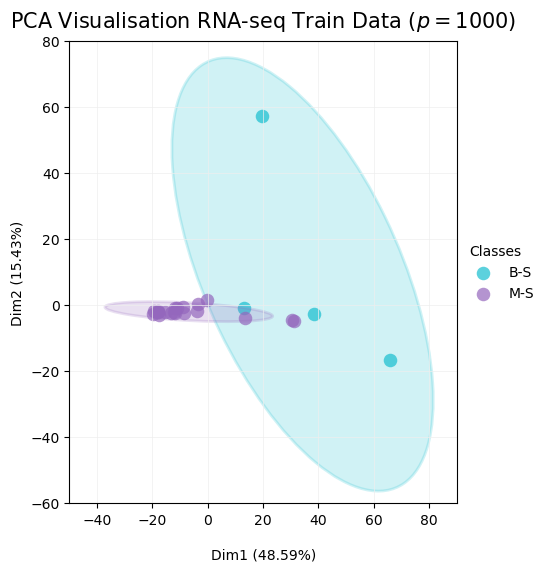

In [59]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")

for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_rna_pca_class["SURGICAL"] == target
    xdata = df_rna_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_rna_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("PCA Visualisation RNA-seq Train Data ($p=1000$)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1 ({:.2f}%)'.format(rna_pca.explained_variance_ratio_[0]*100), fontsize=10, labelpad=15)
ax.set_xlim(-50,90)
ax.set_ylabel('Dim2 ({:.2f}%)'.format(rna_pca.explained_variance_ratio_[1]*100), fontsize=10)
ax.set_ylim(-60,80)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

#### Spearman Rho Correlation Coefficient

In [60]:
# Seperating out the features
rna_all = rna_df.drop(["SURGICAL"], axis=1)
# Seperating out the target
rna_class_cat = pd.Categorical(rna_df["SURGICAL"].astype("category")).codes

In [61]:
rna_thresholds, rna_threshold_counts = spearman_thresh_function(rna_all, rna_class_cat, thresholds)

/tmp/ipykernel_60409/673404981.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(features[column], target)


In [62]:
threshold_df = pd.DataFrame(
    {
        "Threshold": map(str, rna_thresholds),
        "Feature Count": rna_threshold_counts
    }
)

threshold_df

,Threshold,Feature Count
0,0,28694
1,0.1,19463
2,0.2,10440
3,0.3,5437
4,0.4,2266
5,0.5,679
6,0.6,27
7,0.7,0
8,0.8,0
9,0.9,0


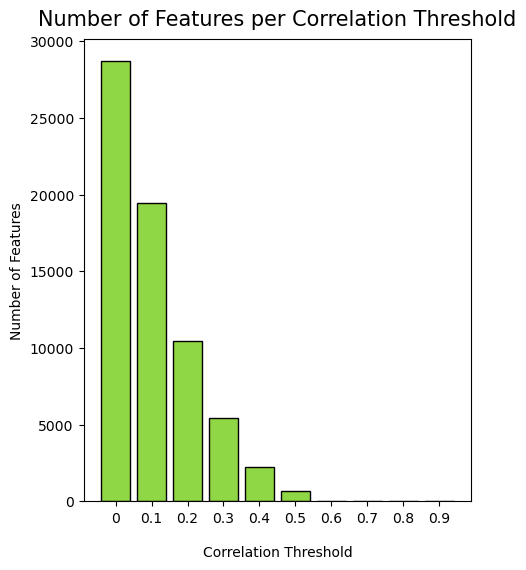

In [63]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.bar(threshold_df["Threshold"], threshold_df["Feature Count"], color="#8FD744FF", edgecolor="black")
ax.set_title("Number of Features per Correlation Threshold", fontsize = 15, pad=10)
ax.set_xlabel("Correlation Threshold", fontsize=10, labelpad=15)
ax.set_ylabel("Number of Features", fontsize=10)
plt.show()

In [64]:
rna_feature_names, rna_feature_correlations = spearman_df_function(rna_all, rna_class_cat, 0.5)

/tmp/ipykernel_60409/189007027.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(features[column], target)


In [65]:
spearman_df = pd.DataFrame(
    {
        "Features": rna_feature_names,
        "Correlations": rna_feature_correlations
    }
)

spearman_df

,Features,Correlations
0,ENSG00000189280,0.570408
1,ENSG00000092853,0.533462
2,ENSG00000134697,0.565301
3,ENSG00000214114,0.565301
4,ENSG00000155761,0.549269
...,...,...
674,ENSG00000099958,0.573501
675,ENSG00000128165,0.508882
676,ENSG00000241484,0.526297
677,ENSG00000142197,0.500695


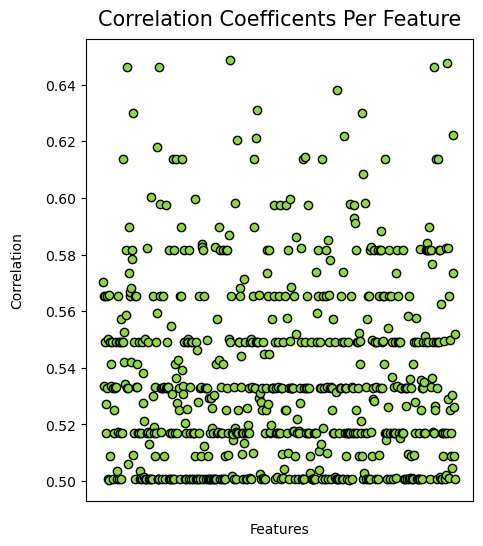

In [66]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.scatter(spearman_df["Features"], spearman_df["Correlations"], color="#8FD744FF", edgecolors="black")
ax.set_title("Correlation Coefficents Per Feature", fontsize = 15, pad=10)
ax.set_xlabel("Features", fontsize=10, labelpad=15)
ax.set_ylabel("Correlation", fontsize=10, labelpad=15)

plt.tick_params(bottom=False, labelbottom=False)
plt.show()

In [67]:
# Store spearman features
spearman_rna = spearman_df["Features"].to_list()

In [68]:
# Seperating out the features
rna_spear = rna_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
rna_spear = rna_spear.loc[:, rna_spear.columns.isin(spearman_rna)]
# Seperating out the target
rna_class = rna_df[["SURGICAL"]]

# Create PCA with 2 components
rna_pca = PCA(n_components=2)
rna_prinComps = rna_pca.fit_transform(rna_spear)

# Print DataFrame
df_rna_princComps = pd.DataFrame(data=rna_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_rna_princComps

,Principal Component 1,Principal Component 2
0,15.933981,9.696740
1,-17.018932,-3.995996
2,-19.587582,-3.917788
3,-21.670569,-5.521512
4,-13.553701,-2.619741
5,27.355887,-4.230134
6,-20.890893,-4.602814
7,-3.317875,-2.781856
8,-6.295137,3.766595
9,-6.123506,-1.467293


In [69]:
# Percentage explained by each component
print(rna_pca.explained_variance_ratio_)

[0.40375708 0.10194954]


In [70]:
# Final dataframe for plotting the data for class
df_rna_pca_class = pd.concat([df_rna_princComps, rna_class], axis=1)

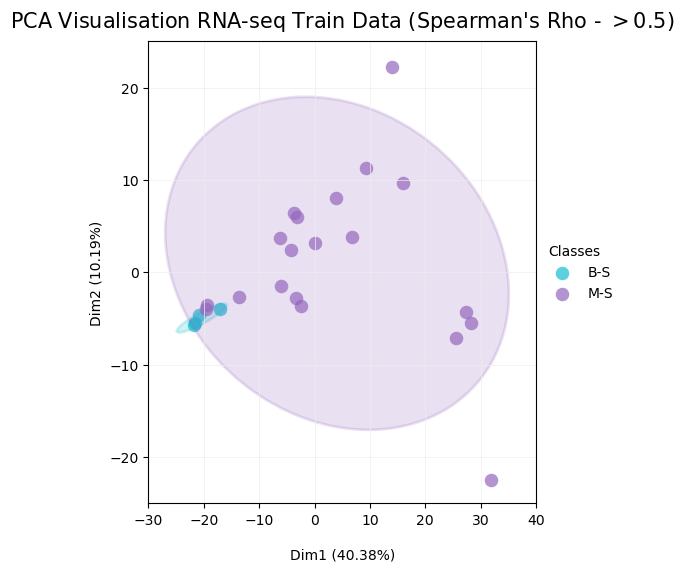

In [71]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")

for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_rna_pca_class["SURGICAL"] == target
    xdata = df_rna_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_rna_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("PCA Visualisation RNA-seq Train Data (Spearman's Rho - $ > 0.5$)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1 ({:.2f}%)'.format(rna_pca.explained_variance_ratio_[0]*100), fontsize=10, labelpad=15)
ax.set_xlim(-30,40)
ax.set_ylabel('Dim2 ({:.2f}%)'.format(rna_pca.explained_variance_ratio_[1]*100), fontsize=10)
ax.set_ylim(-25,25)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

### Radiomics - Principal Component Analysis (2 Components) - Test

#### All features

In [72]:
# Scale radiomics sample counts
scaler = StandardScaler()
rad_df = pd.DataFrame(scaler.fit_transform(rad_test), columns=rad_data_filtered.columns)
rad_df.insert(0, "SURGICAL", surg_test)

In [73]:
rad_df

,SURGICAL,N.voxels,SNS_vol,SNS_area,SNS_s2v,SNS_sph,SNS_sph_dis,SNS_com_1,SNS_com_2,SNS_max3d,...,GLCM_sumVar_HHH_256gl,GLCM_sumEnt_HHH_256gl,GLCM_difVar_HHH_256gl,GLCM_difEnt_HHH_256gl,GLCM_AutoCorrel_HHH_256gl,GLCM_ClTend_HHH_256gl,GLCM_Homoge1_HHH_256gl,GLCM_IDMN_HHH_256gl,GLCM_IDN_HHH_256gl,GLCM_invVar_HHH_256gl
0,B-S,-0.732900,-0.732900,-0.733734,-0.253635,0.192970,-0.518880,-0.505212,-0.104927,-0.846917,...,-0.786969,-0.934757,-0.919029,-0.964660,1.815437,-0.786969,1.449724,0.970797,0.893896,-0.352031
1,M-S,0.582391,0.582391,0.588357,0.006957,-0.605607,0.636334,0.613481,-0.528760,1.043062,...,-0.766793,-0.595419,-0.377737,-0.492936,-0.945055,-0.766793,0.042396,0.591063,0.650746,1.337020
2,B-S,0.314717,0.314717,0.312339,-0.623555,-0.506561,0.441645,0.451677,-0.491920,0.398245,...,-0.962542,-0.846149,-0.827967,-0.885151,-0.008558,-0.962542,0.327089,0.929474,0.947799,1.307821
3,M-S,-0.910950,-0.910950,-0.911981,-0.288283,0.308474,-0.683466,-0.665904,-0.046098,-0.752418,...,-0.741792,-0.428732,-0.667859,-0.473633,-1.352227,-0.741792,-0.459432,0.791819,0.630107,0.334651
4,M-S,-1.542469,-1.542469,-1.541414,2.388572,2.220840,-1.888304,-1.905205,2.391526,-1.571409,...,1.675753,-0.146545,2.101728,-0.075230,0.784987,1.675753,1.098047,-1.591863,-0.739584,-0.918629
5,M-S,0.832075,0.832075,0.829882,-0.645846,-0.715962,0.815869,0.820152,-0.578986,0.362114,...,0.433462,0.978573,0.681012,0.883550,0.254499,0.433462,-0.809220,-0.489951,-0.451251,-0.160827
6,M-S,1.457135,1.457135,1.456552,-0.584210,-0.894153,1.196802,1.191011,-0.640835,1.367323,...,1.148881,1.973030,0.009853,2.008060,-0.549083,1.148881,-1.648604,-1.201340,-1.931712,-1.548005


In [74]:
# Seperating out the features
rad_all = rad_df.drop(["SURGICAL"], axis=1)
# Seperating out the target
rad_class = rad_df[["SURGICAL"]]

# Create PCA with 2 components
rad_pca = PCA(n_components=2)
rad_prinComps = rad_pca.fit_transform(rad_all)

# Print DataFrame
df_rad_princComps = pd.DataFrame(data=rad_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_rad_princComps

,Principal Component 1,Principal Component 2
0,-21.531560,-44.731890
1,-31.689409,16.314356
2,-41.950919,8.389918
3,-24.633846,-4.242195
4,53.554570,-48.048616
5,37.826962,33.919568
6,28.424201,38.398859


In [75]:
# Percentage explained by each component
print(rad_pca.explained_variance_ratio_)

[0.32895916 0.26817138]


In [76]:
# Final dataframe for plotting the data for class
df_rad_pca_class = pd.concat([df_rad_princComps, rad_class], axis=1)

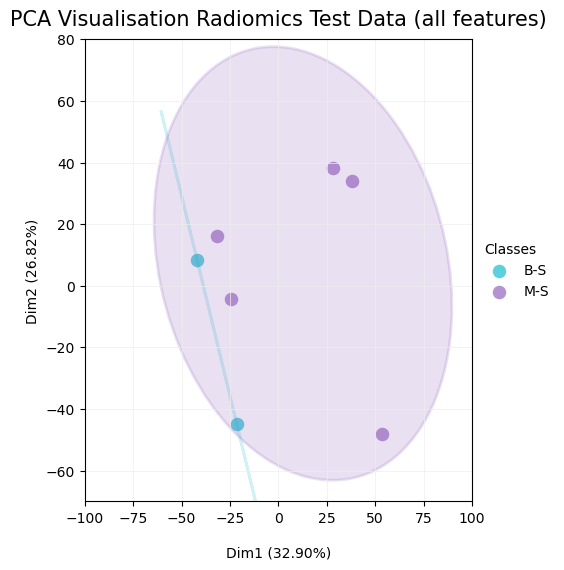

In [77]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")

for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_rad_pca_class["SURGICAL"] == target
    xdata = df_rad_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_rad_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("PCA Visualisation Radiomics Test Data (all features)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1 ({:.2f}%)'.format(rad_pca.explained_variance_ratio_[0]*100), fontsize=10, labelpad=15)
ax.set_xlim(-100,100)
ax.set_ylabel('Dim2 ({:.2f}%)'.format(rad_pca.explained_variance_ratio_[1]*100), fontsize=10)
ax.set_ylim(-70,80)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

#### Run LDA on the Original Dataset to Select Features

In [78]:
# Seperating out the features
rad_1000 = rad_df.drop(["SURGICAL"], axis=1)
# Only keep the top 1000 features
rad_1000 = rad_1000.loc[:, rad_1000.columns.isin(top_1000_rad)]
# Seperating out the target
rad_class = rad_df[["SURGICAL"]]

# Create PCA with 2 components
rad_pca = PCA(n_components=2)
rad_prinComps = rad_pca.fit_transform(rad_1000)

# Print DataFrame
df_rad_princComps = pd.DataFrame(data=rad_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_rad_princComps

,Principal Component 1,Principal Component 2
0,-23.566607,-26.198972
1,-15.075391,15.360690
2,-17.461690,13.352567
3,-1.692109,7.843338
4,16.903546,-19.640178
5,20.744807,9.285164
6,20.147443,-0.002610


In [79]:
# Percentage explained by each component
print(rad_pca.explained_variance_ratio_)

[0.31669375 0.23391022]


In [80]:
# Final dataframe for plotting the data for class
df_rad_pca_class = pd.concat([df_rad_princComps, rad_class], axis=1)

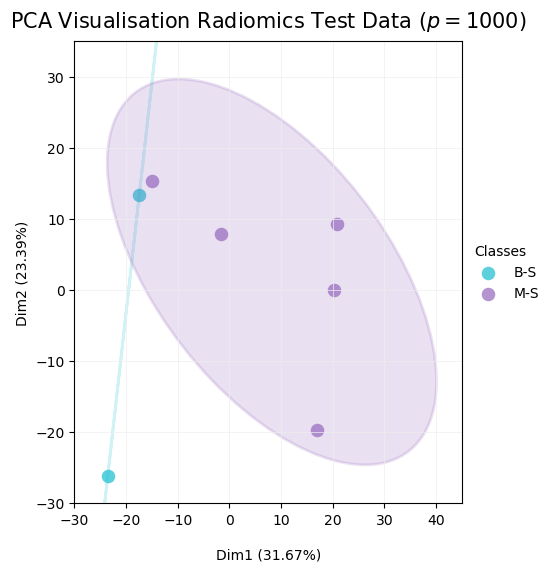

In [81]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")

for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_rad_pca_class["SURGICAL"] == target
    xdata = df_rad_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_rad_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("PCA Visualisation Radiomics Test Data ($p=1000$)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1 ({:.2f}%)'.format(rad_pca.explained_variance_ratio_[0]*100), fontsize=10, labelpad=15)
ax.set_xlim(-30,45)
ax.set_ylabel('Dim2 ({:.2f}%)'.format(rad_pca.explained_variance_ratio_[1]*100), fontsize=10)
ax.set_ylim(-30,35)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

#### Spearman Rho Correlation Coefficient

In [82]:
# Seperating out the features
rad_spear = rad_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
rad_spear = rad_spear.loc[:, rad_spear.columns.isin(spearman_rad)]
# Seperating out the target
rad_class = rad_df[["SURGICAL"]]

# Create PCA with 2 components
rad_pca = PCA(n_components=2)
rad_prinComps = rad_pca.fit_transform(rad_spear)

# Print DataFrame
df_rad_princComps = pd.DataFrame(data=rad_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_rad_princComps

,Principal Component 1,Principal Component 2
0,-9.430757,6.921011
1,2.895468,0.509864
2,5.265121,3.016767
3,-0.554292,0.981669
4,-9.546390,-8.078565
5,6.843947,-5.825552
6,4.526904,2.474806


In [83]:
# Percentage explained by each component
print(rad_pca.explained_variance_ratio_)

[0.41799361 0.24086868]


In [84]:
# Final dataframe for plotting the data for class
df_rad_pca_class = pd.concat([df_rad_princComps, rad_class], axis=1)

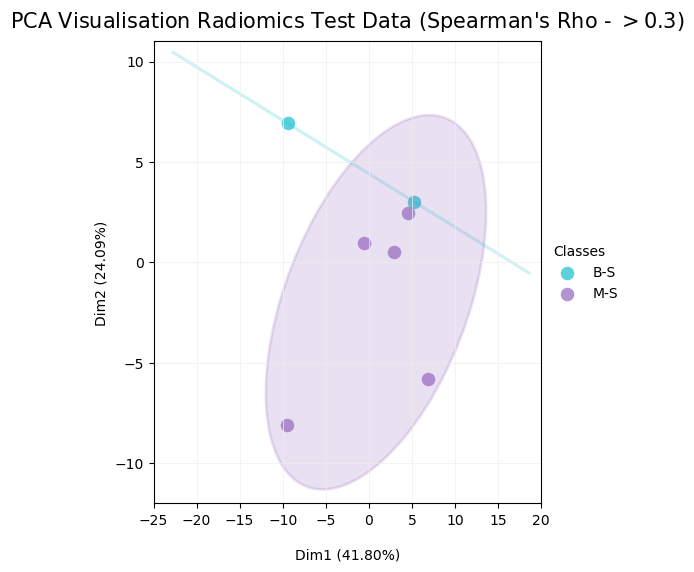

In [85]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")

for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_rad_pca_class["SURGICAL"] == target
    xdata = df_rad_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_rad_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("PCA Visualisation Radiomics Test Data (Spearman's Rho - $ > 0.3$)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1 ({:.2f}%)'.format(rad_pca.explained_variance_ratio_[0]*100), fontsize=10, labelpad=15)
ax.set_xlim(-25,20)
ax.set_ylabel('Dim2 ({:.2f}%)'.format(rad_pca.explained_variance_ratio_[1]*100), fontsize=10)
ax.set_ylim(-12,11)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

### RNA - Principal Component Analysis (2 Components)

#### All features

In [86]:
# Scale RNA sample counts
scaler = StandardScaler()
rna_df = pd.DataFrame(scaler.fit_transform(rna_test), columns=rna_data_filtered.columns)
rna_df.insert(0, "SURGICAL", surg_test)

In [87]:
rna_df

1,SURGICAL,ENSG00000279928,ENSG00000228037,ENSG00000142611,ENSG00000284616,ENSG00000157911,ENSG00000260972,ENSG00000224340,ENSG00000226374,ENSG00000229280,...,ENSG00000198886,ENSG00000210176,ENSG00000210184,ENSG00000210191,ENSG00000198786,ENSG00000198695,ENSG00000210194,ENSG00000198727,ENSG00000210195,ENSG00000210196
0,B-S,-0.632456,0.051743,-0.634145,0.0,-0.971436,0.0,0.0,0.0,0.0,...,-0.177757,-0.408248,0.0,2.157277,1.065944,1.812009,1.931136,-0.083234,0.0,0.612336
1,M-S,1.581139,0.232845,-1.075908,0.0,-2.010404,0.0,0.0,0.0,0.0,...,2.379534,2.449490,0.0,-0.588348,1.903930,0.507941,0.412265,2.418272,0.0,2.138808
2,B-S,-0.632456,-0.189726,-0.819400,0.0,0.540264,0.0,0.0,0.0,0.0,...,-0.278583,-0.408248,0.0,-0.588348,-0.892179,0.739639,0.564152,-0.413311,0.0,-0.758305
3,M-S,-0.632456,0.534681,1.859683,0.0,0.987020,0.0,0.0,0.0,0.0,...,-0.750027,-0.408248,0.0,-0.588348,-0.944299,-1.309031,-0.954719,-0.670685,0.0,-0.713664
4,M-S,-0.632456,-1.095235,0.057002,0.0,0.394808,0.0,0.0,0.0,0.0,...,-0.604475,-0.408248,0.0,-0.588348,-0.172974,-0.253262,-1.258493,-0.385950,0.0,0.099793
5,M-S,1.581139,-1.397071,-0.441764,0.0,0.405198,0.0,0.0,0.0,0.0,...,-0.547954,-0.408248,0.0,0.784465,-0.653424,-0.828969,-0.499057,-0.457419,0.0,-0.741771
6,M-S,-0.632456,1.862761,1.054533,0.0,0.654550,0.0,0.0,0.0,0.0,...,-0.020738,-0.408248,0.0,-0.588348,-0.306997,-0.668327,-0.195283,-0.407674,0.0,-0.637196


In [88]:
# Seperating out the features
rna_all = rna_df.drop(["SURGICAL"], axis=1)
# Seperating out the target
rna_class = rna_df[["SURGICAL"]]

# Create PCA with 2 components
rna_pca = PCA(n_components=2)
rna_prinComps = rna_pca.fit_transform(rna_all)

# Create DataFrame
df_rna_princComps = pd.DataFrame(data=rna_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_rna_princComps

,Principal Component 1,Principal Component 2
0,-120.205789,-55.049936
1,179.030368,-177.757708
2,-100.624141,-57.799730
3,26.815173,86.005450
4,-110.696074,-24.731871
5,61.575743,140.251071
6,64.104720,89.082723


In [89]:
# Percentage explained by each component
print(rna_pca.explained_variance_ratio_)

[0.27266235 0.25888369]


In [90]:
# Final dataframe for plotting the data for class
df_rna_pca_class = pd.concat([df_rna_princComps, rna_class], axis=1)

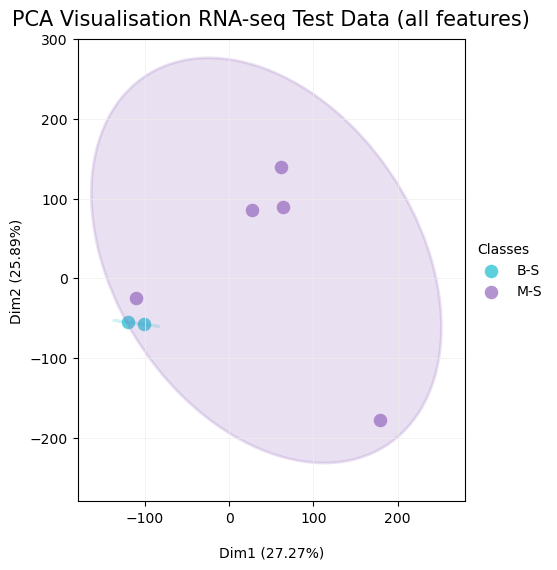

In [91]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")

for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_rna_pca_class["SURGICAL"] == target
    xdata = df_rna_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_rna_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("PCA Visualisation RNA-seq Test Data (all features)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1 ({:.2f}%)'.format(rna_pca.explained_variance_ratio_[0]*100), fontsize=10, labelpad=15)
ax.set_xlim(-180,280)
ax.set_ylabel('Dim2 ({:.2f}%)'.format(rna_pca.explained_variance_ratio_[1]*100), fontsize=10)
ax.set_ylim(-280,300)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

#### Run LDA on the Original Dataset to Select Features

In [92]:
# Seperating out the features
rna_1000 = rna_df.drop(["SURGICAL"], axis=1)
# Only keep the top 1000 features
rna_1000 = rna_1000.loc[:, rna_1000.columns.isin(top_1000_rna)]
# Seperating out the target
rna_class = rna_df[["SURGICAL"]]

# Create PCA with 2 components
rna_pca = PCA(n_components=2)
rna_prinComps = rna_pca.fit_transform(rna_1000)

# Create DataFrame
df_rna_princComps = pd.DataFrame(data=rna_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_rna_princComps

,Principal Component 1,Principal Component 2
0,33.059571,-12.405576
1,-24.569817,-2.112956
2,14.167554,-14.387952
3,-14.973003,-0.203272
4,22.819806,26.309728
5,-13.322353,1.744597
6,-17.181758,1.055431


In [93]:
# Percentage explained by each component
print(rna_pca.explained_variance_ratio_)

[0.51148818 0.17434757]


In [94]:
# Final dataframe for plotting the data for class
df_rna_pca_class = pd.concat([df_rna_princComps, rna_class], axis=1)

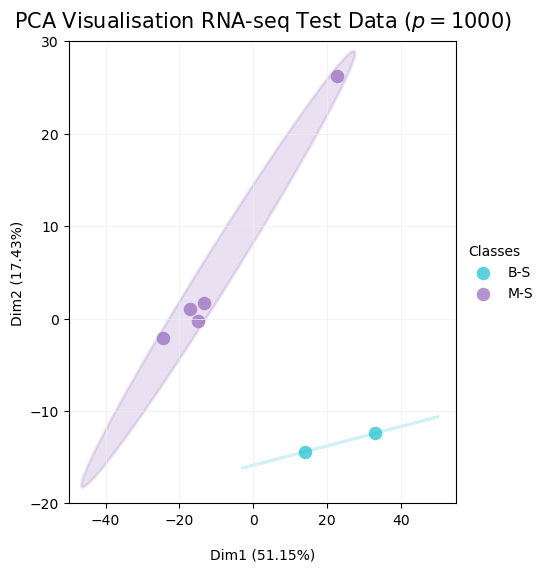

In [95]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")

for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_rna_pca_class["SURGICAL"] == target
    xdata = df_rna_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_rna_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("PCA Visualisation RNA-seq Test Data ($p=1000$)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1 ({:.2f}%)'.format(rna_pca.explained_variance_ratio_[0]*100), fontsize=10, labelpad=15)
ax.set_xlim(-50,55)
ax.set_ylabel('Dim2 ({:.2f}%)'.format(rna_pca.explained_variance_ratio_[1]*100), fontsize=10)
ax.set_ylim(-20,30)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

#### Spearman Rho Correlation Coefficient

In [96]:
# Seperating out the features
rna_spear = rna_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
rna_spear = rna_spear.loc[:, rna_spear.columns.isin(spearman_rna)]
# Seperating out the target
rna_class = rna_df[["SURGICAL"]]

# Create PCA with 2 components
rna_pca = PCA(n_components=2)
rna_prinComps = rna_pca.fit_transform(rna_spear)

# Print DataFrame
df_rna_princComps = pd.DataFrame(data=rna_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_rna_princComps

,Principal Component 1,Principal Component 2
0,-18.829478,-3.297547
1,0.207529,30.428802
2,-17.517956,-6.102691
3,22.852225,-2.476500
4,-20.195673,-5.190408
5,15.138873,-6.728770
6,18.344480,-6.632887


In [97]:
# Percentage explained by each component
print(rna_pca.explained_variance_ratio_)

[0.45387459 0.2306698 ]


In [98]:
# Final dataframe for plotting the data for class
df_rna_pca_class = pd.concat([df_rna_princComps, rna_class], axis=1)

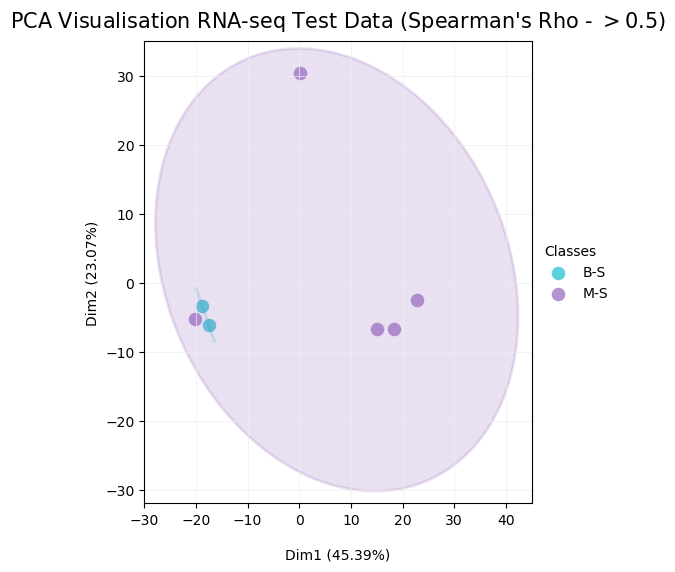

In [99]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")

for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_rna_pca_class["SURGICAL"] == target
    xdata = df_rna_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_rna_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("PCA Visualisation RNA-seq Test Data (Spearman's Rho - $ > 0.5$)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1 ({:.2f}%)'.format(rna_pca.explained_variance_ratio_[0]*100), fontsize=10, labelpad=15)
ax.set_xlim(-30,45)
ax.set_ylabel('Dim2 ({:.2f}%)'.format(rna_pca.explained_variance_ratio_[1]*100), fontsize=10)
ax.set_ylim(-32,35)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()